In [ ]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from typing import List

# Locals
from utils import *
from dataset import Dataset, SlidingWindowDataset
from models import *
from dlnr import DLNoiseReduction

In [ ]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

# Functions

In [ ]:
def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

# Load data

In [ ]:
df = pd.read_csv(os.path.join(DATA_PATH, 'Informer_Datasets', 'WTH', 'WTH.csv'))
df

,date,Visibility,DryBulbFarenheit,DryBulbCelsius,WetBulbFarenheit,DewPointFarenheit,DewPointCelsius,RelativeHumidity,WindSpeed,WindDirection,StationPressure,Altimeter,WetBulbCelsius
0,1/1/2010 0:00,10.0,16,-9,13,7,-14,67,7,130,21.650000,30.35,-10.3
1,1/1/2010 1:00,10.0,16,-9,13,7,-14,67,5,150,21.640000,30.34,-10.3
2,1/1/2010 2:00,10.0,16,-9,13,7,-14,67,5,190,21.650000,30.35,-10.3
3,1/1/2010 3:00,10.0,16,-9,13,7,-14,67,7,180,21.650000,30.35,-10.3
4,1/1/2010 4:00,10.0,16,-9,14,9,-13,74,6,120,21.640000,30.34,-10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,12/31/2013 19:00,10.0,32,0,0,23,-5,0,0,0,21.478686,30.21,0.0
35060,12/31/2013 20:00,7.0,30,-1,0,25,-4,0,5,110,21.478686,30.21,0.0
35061,12/31/2013 21:00,5.0,30,-1,0,28,-2,0,0,0,21.478686,30.20,0.0
35062,12/31/2013 22:00,10.0,30,-1,0,28,-2,0,5,140,21.478686,30.18,0.0


In [ ]:
df.index = pd.to_datetime(df['date'])
df.drop(columns=['date'], inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Visibility,35064.0,9.385894,2.034966,0.00,10.00,10.00,10.00,10.00
DryBulbFarenheit,35064.0,42.979438,17.068807,-15.00,30.00,43.00,55.00,86.00
DryBulbCelsius,35064.0,6.125000,9.420843,-26.00,-1.00,6.00,13.00,30.00
WetBulbFarenheit,35064.0,33.717944,12.689218,-16.00,25.00,33.00,44.00,61.00
DewPointFarenheit,35064.0,21.713068,14.507766,-29.00,12.00,19.00,32.00,59.00
DewPointCelsius,35064.0,-5.677247,8.037367,-34.00,-11.00,-7.00,0.00,15.00
RelativeHumidity,35064.0,49.843344,25.143403,0.00,29.00,48.00,69.00,100.00
WindSpeed,35064.0,5.651580,4.845549,0.00,0.00,6.00,8.00,38.00
WindDirection,35064.0,132.617528,102.147659,0.00,0.00,130.00,230.00,360.00
StationPressure,35064.0,21.530753,0.174853,20.66,21.42,21.56,21.67,21.88


In [ ]:
for col in df.columns:
    print(len(np.unique(df[col])))

15
57
57
76
50
50
96
32
38
120
155
361


<Axes: >

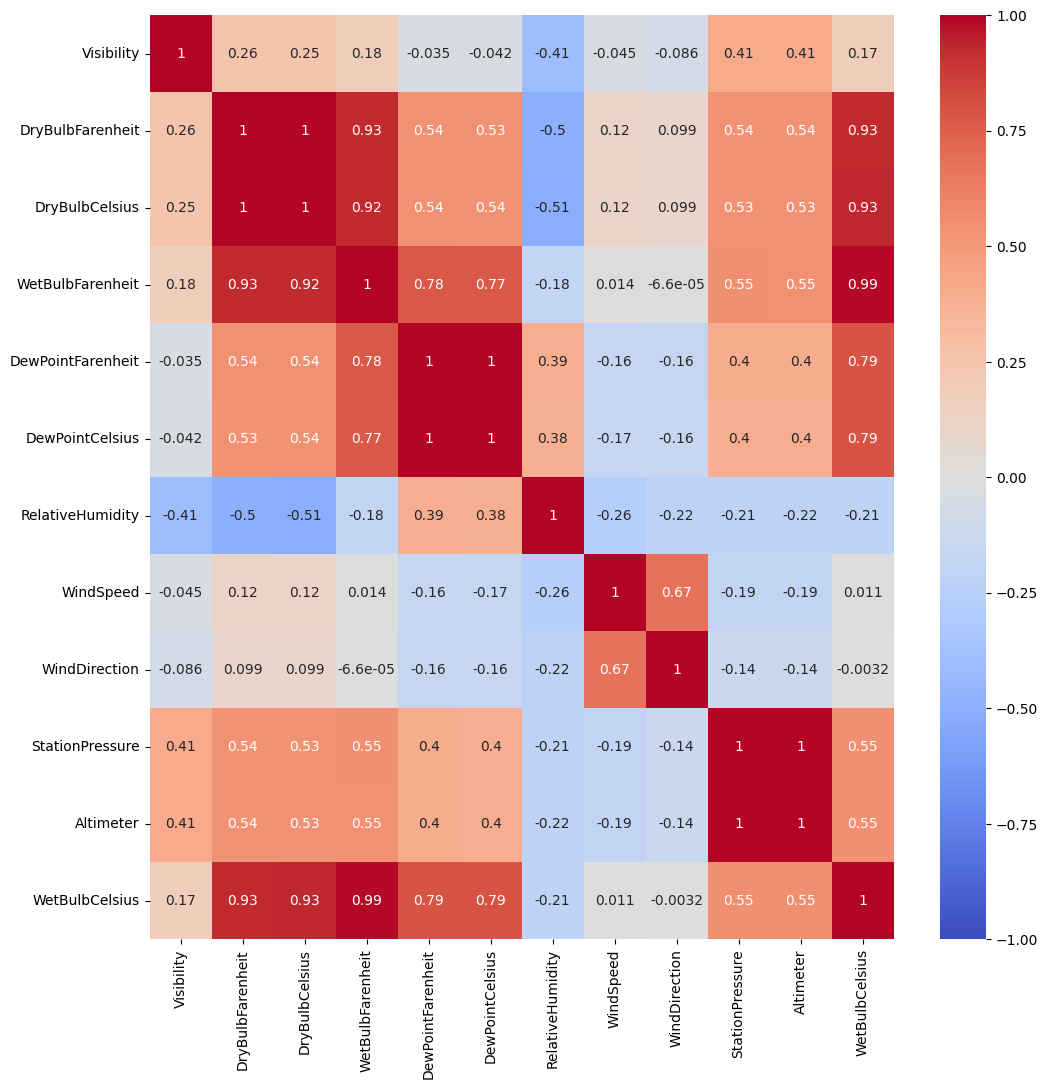

In [ ]:
corr = df.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [ ]:
df_small = df[df.columns[1:6]]
df_small['y'] = df[df.columns[-1:]]

/tmp/ipykernel_3674205/2642242864.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['y'] = df[df.columns[-1:]]


<Axes: >

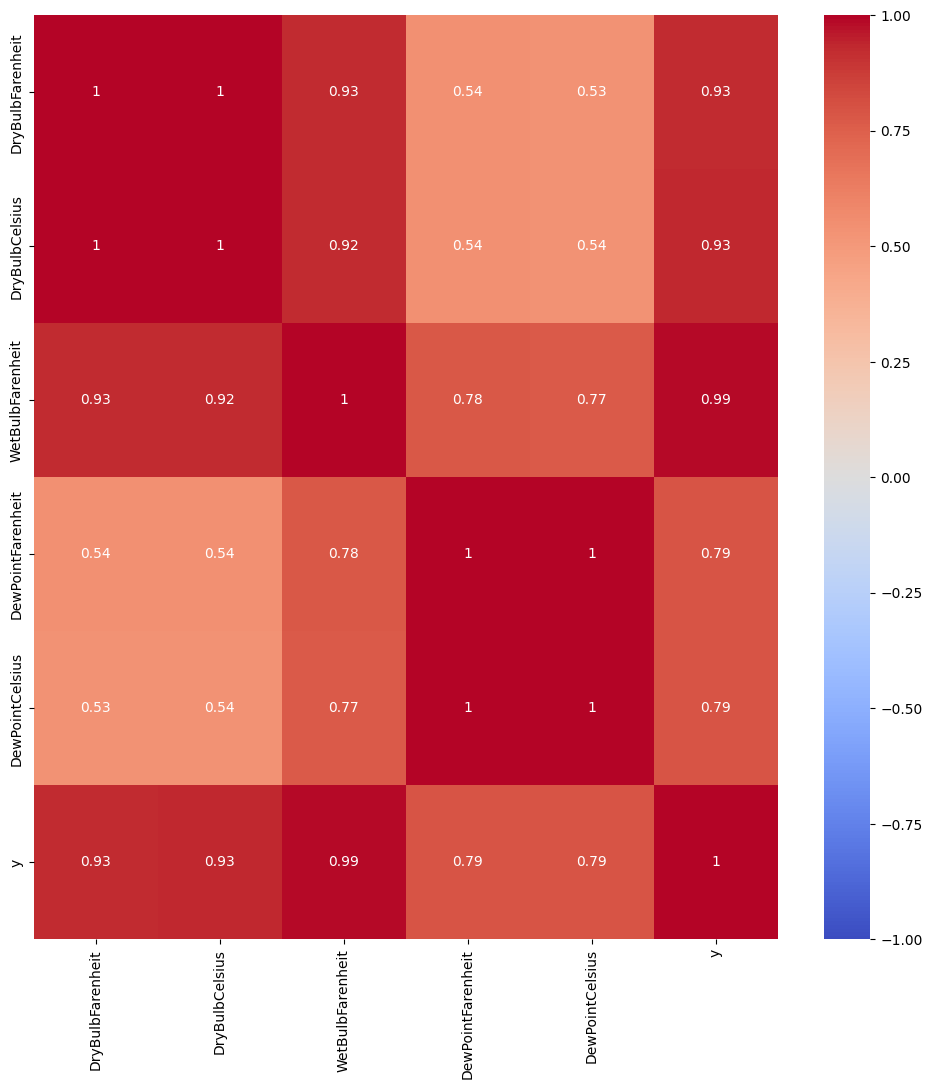

In [ ]:
corr = df_small.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [ ]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_small)
df_scaled = pd.DataFrame(df_scaled, columns=df_small.columns)
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
DryBulbFarenheit,35064.0,0.574054,0.168998,0.0,0.445545,0.574257,0.693069,1.0
DryBulbCelsius,35064.0,0.573661,0.168229,0.0,0.446429,0.571429,0.696429,1.0
WetBulbFarenheit,35064.0,0.645688,0.164795,0.0,0.532468,0.636364,0.779221,1.0
DewPointFarenheit,35064.0,0.576285,0.164861,0.0,0.465909,0.545455,0.693182,1.0
DewPointCelsius,35064.0,0.578015,0.164028,0.0,0.469388,0.551020,0.693878,1.0
y,35064.0,0.642297,0.161554,0.0,0.529274,0.632319,0.772834,1.0


In [ ]:
sigma = 0.1
df_noisy = add_gaussian_noise(
        df=df_scaled.copy(),
        columns=[x for x in df_scaled.columns],
        mean=0,
        std=sigma
)
display(df_scaled.describe().T)
display(df_noisy.describe().T)

,count,mean,std,min,25%,50%,75%,max
DryBulbFarenheit,35064.0,0.574054,0.168998,0.0,0.445545,0.574257,0.693069,1.0
DryBulbCelsius,35064.0,0.573661,0.168229,0.0,0.446429,0.571429,0.696429,1.0
WetBulbFarenheit,35064.0,0.645688,0.164795,0.0,0.532468,0.636364,0.779221,1.0
DewPointFarenheit,35064.0,0.576285,0.164861,0.0,0.465909,0.545455,0.693182,1.0
DewPointCelsius,35064.0,0.578015,0.164028,0.0,0.469388,0.551020,0.693878,1.0
y,35064.0,0.642297,0.161554,0.0,0.529274,0.632319,0.772834,1.0


,count,mean,std,min,25%,50%,75%,max
DryBulbFarenheit,35064.0,0.574243,0.196538,-0.143273,0.433172,0.571678,0.716146,1.262249
DryBulbCelsius,35064.0,0.573616,0.196252,-0.168644,0.433177,0.571431,0.715955,1.206547
WetBulbFarenheit,35064.0,0.646275,0.193218,-0.192923,0.514003,0.645351,0.786106,1.250436
DewPointFarenheit,35064.0,0.576025,0.192694,-0.140028,0.443515,0.567483,0.706068,1.248704
DewPointCelsius,35064.0,0.577670,0.192436,-0.216588,0.443348,0.569527,0.708278,1.252321
y,35064.0,0.643198,0.190631,-0.194635,0.512339,0.642047,0.781154,1.317139


<Axes: >

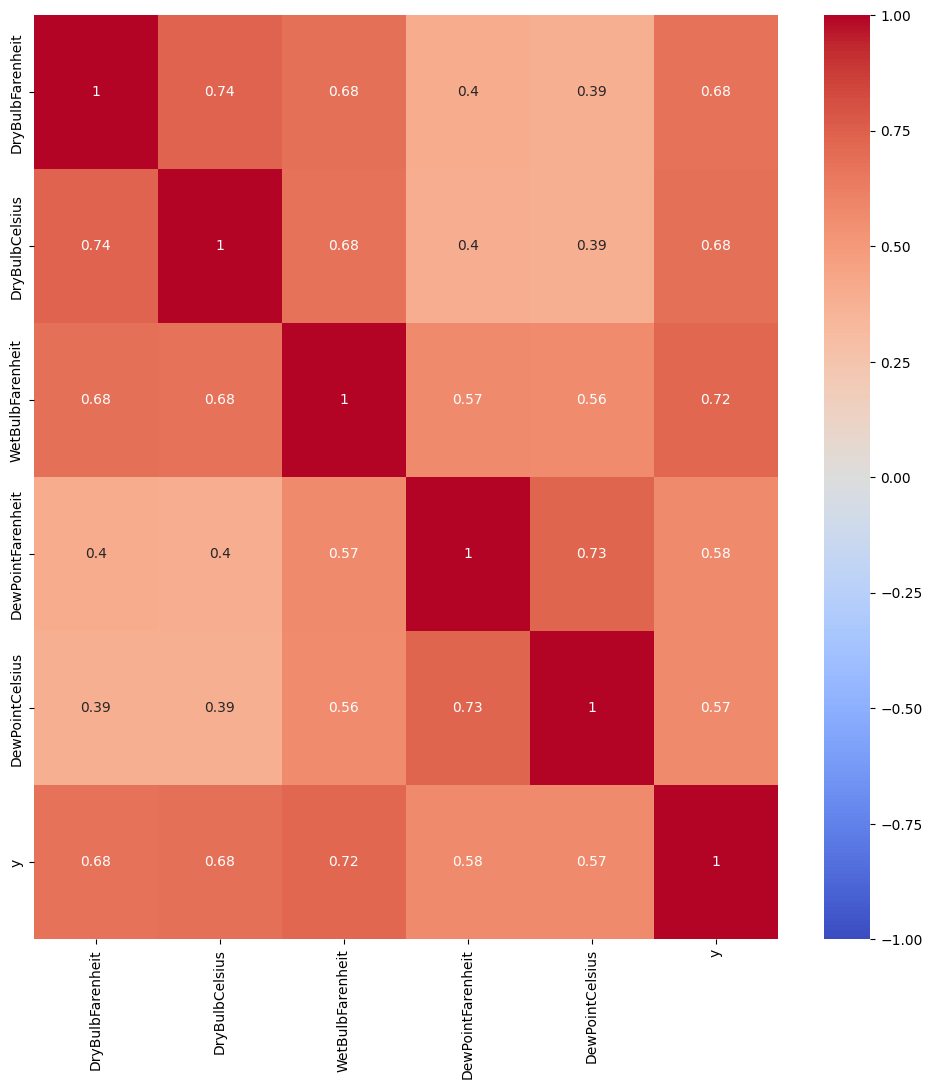

In [ ]:
corr = df_noisy.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

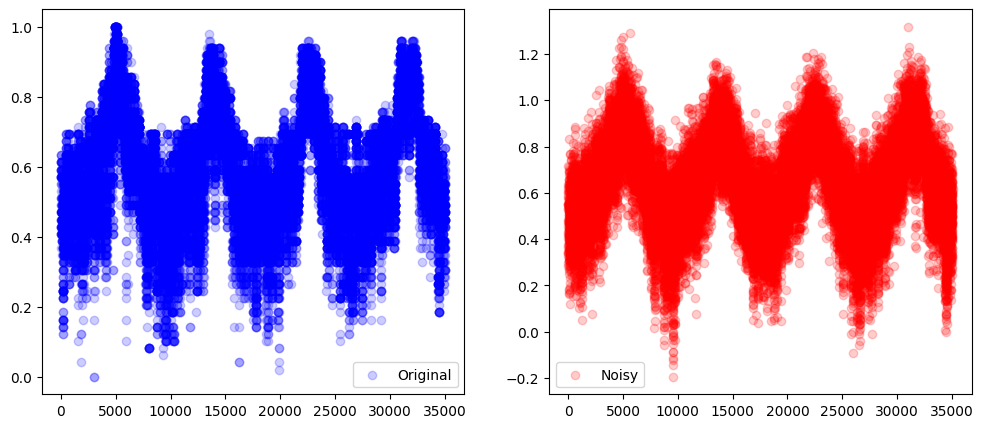

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(range(len(df_scaled['DewPointCelsius'])), df_scaled['DewPointCelsius'], alpha=0.2, c='b', label='Original')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(range(len(df_noisy['y'])), df_noisy['y'], alpha=0.2, c='r', label='Noisy')
plt.legend()

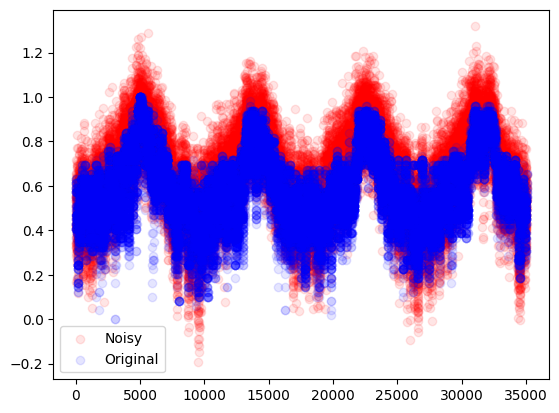

In [ ]:
plt.scatter(range(len(df_noisy['y'])), df_noisy['y'], alpha=0.1, c='r', label='Noisy')
plt.scatter(range(len(df_scaled['DewPointCelsius'])), df_scaled['DewPointCelsius'], alpha=0.1, c='b', label='Original')
plt.legend()

In [ ]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df_noisy[df_noisy.columns[:-1]], df_noisy[df_noisy.columns[-1]], test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [ ]:
window_size = 1

In [ ]:
train_dataset = SlidingWindowDataset(X_train, y_train, window_size=window_size, future=1)
val_dataset = SlidingWindowDataset(X_val, y_val, window_size=window_size, future=1)
test_dataset = SlidingWindowDataset(X_test, y_test, window_size=window_size, future=1)

In [ ]:
input_size = X_train.shape[-1] * window_size # Número de variables de entrada
hidden_size = 128  # Número de neuronas en la capa oculta
output_size = 1  # Predicción de una variable

# Crear el modelo
model = DenseTemporalModel(input_size, hidden_size, output_size).to(device)

# Definir la función de pérdida y el optimizador
criterion = nn.MSELoss()  # Error cuadrático medio
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Load checkpoint
# Comment if you want to train the model
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, 'WTH','dense_sigma0.1.pth')))

<All keys matched successfully>

In [ ]:
trainer = Trainer(
    model = model,
    train_generator = train_dataloader,
    val_generator = val_dataloader,
    device = device,
    criterion = criterion,
    optimizer = optimizer,
    epoch_scheduler = None,
    batch_scheduler = None,
    patience = 10,
    epochs = 500,
    checkpoints_path = os.path.join(CHECKPOINT_PATH, 'WTH', f'dense_sigma{sigma}'),
)

In [ ]:
# Train the model
# Comment if you want to load the model
# trainer.fit(verbose=True)

In [ ]:
predictions = trainer.eval_dataloader(test_dataloader)
len(predictions)

220

In [ ]:
predictions_flattened = np.array([y.cpu().detach().numpy() for x in predictions for y in x])
len(predictions_flattened)

7012

In [ ]:
# predictions = predictions[0].cpu().detach().numpy()
# predictions = predictions.flatten()

In [ ]:
test_to_compare = y_test.values[window_size:]

In [ ]:
mse = mean_squared_error(test_to_compare, predictions_flattened)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_to_compare, predictions_flattened)
r2 = r2_score(test_to_compare, predictions_flattened)

In [ ]:
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2: {r2:.4f}')

MSE: 0.0125
RMSE: 0.1120
MAE: 0.0889
R2: 0.6335


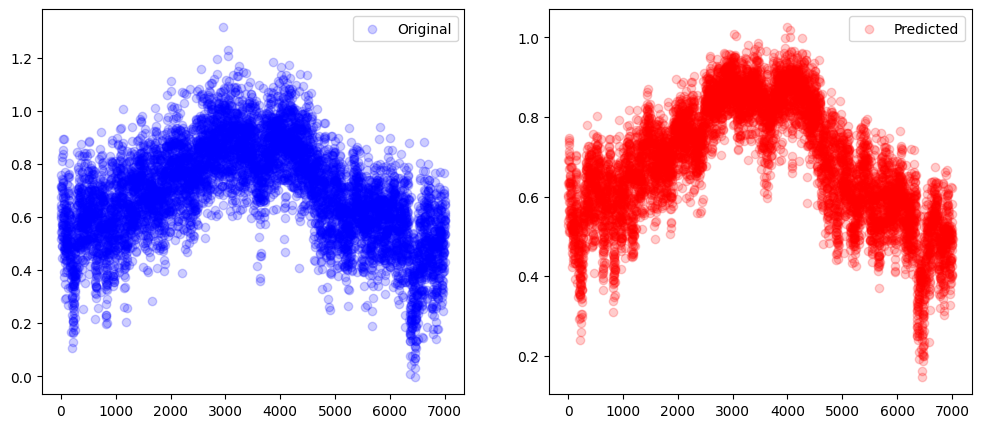

In [31]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(range(len(y_test)), y_test, alpha=0.2, c='b', label='Original')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(range(len(predictions_flattened)), predictions_flattened, alpha=0.2, c='r', label='Predicted')
plt.legend()

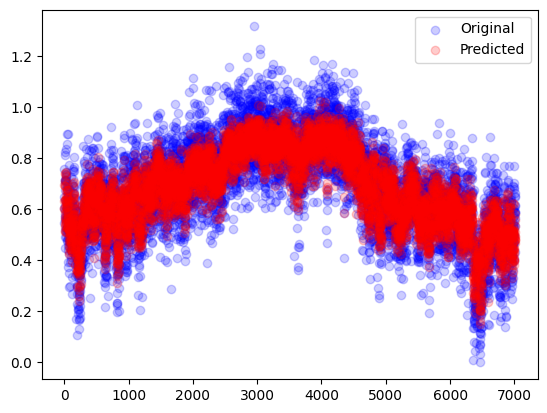

In [32]:
plt.scatter(range(len(y_test)), y_test, alpha=0.2, c='b', label='Original')
plt.scatter(range(len(predictions_flattened)), predictions_flattened, alpha=0.2, c='r', label='Predicted')
plt.legend()

# Gradients to reduce noise

In [33]:
x_cols = df_noisy.columns[:-1]
df_to_denoise = SlidingWindowDataset(df_noisy[x_cols], df_noisy['y'], window_size=window_size, future=1)

In [34]:
df_no_noise = df_noisy.copy()
dlnr = DLNoiseReduction(model=model, criterion=criterion, is_ts=True)
dlnr.fit(df_to_denoise)

In [35]:
X_denoised, y_denoised = dlnr.transform(
    nrr=0.01,
    nr_threshold=0.01,
    max_epochs=500,
    plot_progress=False
)

AttributeError: 'NoneType' object has no attribute 'copy'

In [ ]:
dlnr.assert_improvement(
    x_denoised = df_no_noise[['x0', 'x1']].values.reshape(-1, 2),
    y_denoised = df_no_noise[['y']].values.reshape(-1, 1),
    x_orig = df_train[['x0', 'x1']].values.reshape(-1, 2),
    y_orig = df_train[['y']].values.reshape(-1, 1)
)

KeyError: "None of [Index(['x0', 'x1'], dtype='object')] are in the [columns]"